# 06. Hanam Gyosan Risk Prediction

본 단계에서는 기존 신도시 분석을 통해 도출한 사고 위험 패턴을 하남교산 계획 데이터에 적용하여,
잠재적 교통사고 위험 지역을 예측하고자 한다.

구체적으로 다음을 수행한다.

1. 하남교산 격자 단위 예측 데이터 확인
2. 리스크 스코어 분포 및 고위험 지역 도출
3. 고위험 격자의 구조적 특성 파악
4. 향후 교통안전 시설 설치 우선 검토 지역 제안

이를 통해 아직 조성 단계에 있는 신도시에서도
사고 발생 가능성이 높은 공간을 사전에 식별하고,
예방적 교통안전 대책 수립에 활용할 수 있는 근거를 제시한다.

In [1]:
# 라이브러리 및 기본설정

import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

from shapely import wkt
from shapely.geometry.base import BaseGeometry
sns.set_theme(
    style="whitegrid",
    palette="deep",
    context="notebook",
    font_scale=1.15
)

plt.rcParams["figure.figsize"] = (10, 6)
mpl.rcParams["axes.unicode_minus"] = False

In [2]:
# 데이터 불러오기
# 예측 feature 파일 : 02_pred_base_final_features_gyosan.csv
# 최종 risk score : 02_gyosan_risk_score_final.csv

pred_path = "../outputs/processed/02_pred_base_final_features_gyosan.csv"
risk_path = "../outputs/processed/02_gyosan_risk_score_final.csv"

pred_df = pd.read_csv(pred_path)
risk_df = pd.read_csv(risk_path)

print("pred_df:", pred_df.shape)
print("risk_df:", risk_df.shape)

pred_df: (1302, 11)
risk_df: (770, 8)


In [3]:
print(pred_df.columns.tolist())
print()
print(risk_df.columns.tolist())

['gid', 'city', 'geometry', 'resident_pop', 'blockType_main', 'landuse_group', 'is_residential', 'is_commercial', 'is_green', 'is_road', 'is_public']

['gid', 'city', 'blockType_main', 'risk_prob', 'risk_intensity', 'risk_score', 'risk_rank_pct', 'risk_grade']


## 하남교산 예측 데이터 확인

하남교산 데이터는 기존 사고 이력이 없는 계획 단계 도시이므로,
기존 신도시에서 구축한 설명변수 체계를 동일하게 적용한 예측용 격자 데이터로 구성된다.

이 데이터에는 인구, 교통, 보행·안전 시설, 토지이용 관련 변수들이 포함되며,
이를 바탕으로 격자별 위험 수준을 추정한다.

In [6]:
# geometry 컬럼이 없어서 geojson 사용
risk_gdf = gpd.read_file("../outputs/processed/02_gyosan_risk_score_final.geojson")
print(risk_gdf.shape)
print(risk_gdf.crs)
risk_gdf.head()

(770, 9)
EPSG:4326


,gid,city,blockType_main,risk_prob,risk_intensity,risk_score,risk_rank_pct,risk_grade,geometry
0,다사720443,경기도 하남시,경관녹지,0.032243,0.053430,0.001723,0.155195,Low,"POLYGON ((127.18323 37.49754, 127.18323 37.498..."
1,다사720444,경기도 하남시,단독주택,0.067375,0.093779,0.006318,0.612987,Medium,"POLYGON ((127.18323 37.49844, 127.18323 37.499..."
2,다사721443,경기도 하남시,단독주택,0.065543,0.095327,0.006248,0.608442,Medium,"POLYGON ((127.18436 37.49754, 127.18436 37.498..."
3,다사721444,경기도 하남시,단독주택,0.065543,0.095327,0.006248,0.608442,Medium,"POLYGON ((127.18436 37.49844, 127.18436 37.499..."
4,다사721445,경기도 하남시,경관녹지,0.031334,0.054312,0.001702,0.103247,Low,"POLYGON ((127.18436 37.49934, 127.18435 37.500..."


In [7]:
# risk score 변수 확인

risk_gdf.columns.tolist()

['gid',
 'city',
 'blockType_main',
 'risk_prob',
 'risk_intensity',
 'risk_score',
 'risk_rank_pct',
 'risk_grade',
 'geometry']

In [8]:
risk_gdf.select_dtypes(include=["int64", "float64"]).columns.tolist()

['risk_prob', 'risk_intensity', 'risk_score', 'risk_rank_pct']

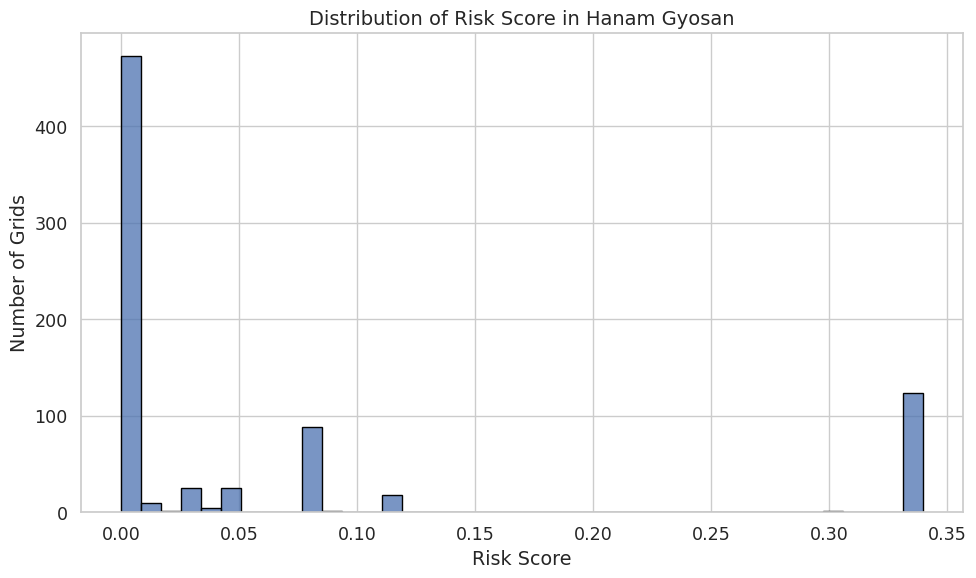

In [10]:
# Risk Score 분포 분석

score_col = "risk_score"

plt.figure(figsize=(10,6))

sns.histplot(
    data=risk_gdf,
    x=score_col,
    bins=40,
    color="#4C72B0",
    edgecolor="black"
)

plt.title("Distribution of Risk Score in Hanam Gyosan", fontsize=14)
plt.xlabel("Risk Score")
plt.ylabel("Number of Grids")

plt.tight_layout()
plt.show()

## 하남교산 리스크 스코어 분포

격자별 리스크 스코어 분포를 확인한 결과 대부분의 격자는 낮은 위험 수준에 위치하지만,
일부 격자는 상대적으로 높은 위험 점수를 보였다.

- 이는 계획 단계 도시에서도 교통사고 위험이 공간적으로 균등하게 나타나는 것이 아니라,
특정 격자에서 상대적으로 높은 위험이 나타날 가능성이 있음을 의미한다.

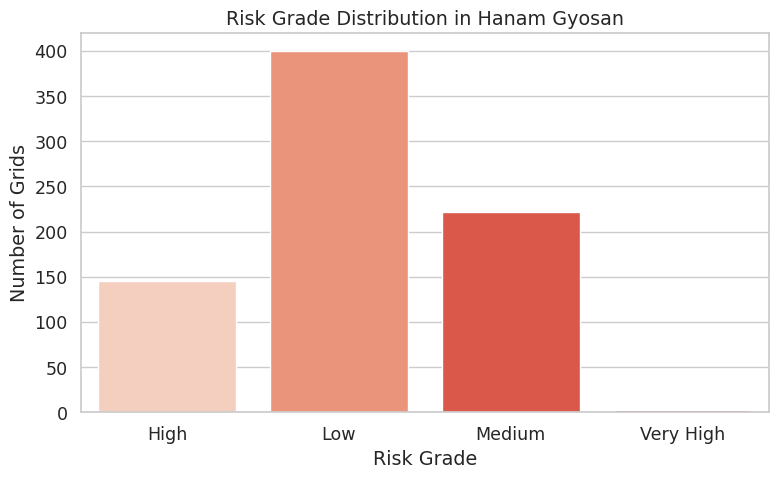

In [11]:
# Risk Grade 분포 확인하기

risk_grade_counts = risk_gdf["risk_grade"].value_counts().sort_index()
risk_grade_counts

plt.figure(figsize=(8,5))

sns.barplot(
    x=risk_grade_counts.index,
    y=risk_grade_counts.values,
    palette="Reds"
)

plt.title("Risk Grade Distribution in Hanam Gyosan")
plt.xlabel("Risk Grade")
plt.ylabel("Number of Grids")

plt.tight_layout()
plt.show()

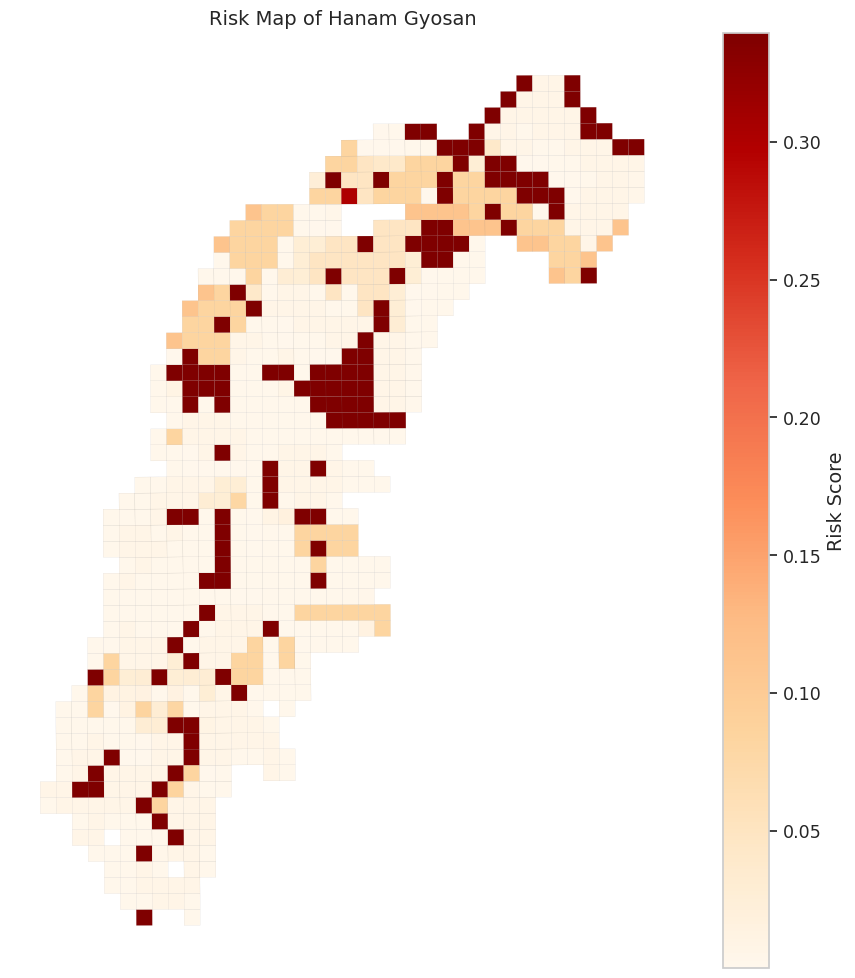

In [12]:
# Risk Map

fig, ax = plt.subplots(figsize=(10,10))

risk_gdf.plot(
    column="risk_score",
    cmap="OrRd",
    linewidth=0.05,
    edgecolor="gray",
    legend=True,
    ax=ax,
    legend_kwds={"label": "Risk Score"}
)

ax.set_title("Risk Map of Hanam Gyosan", fontsize=14)
ax.axis("off")

plt.tight_layout()
plt.show()

## 하남교산 교통사고 리스크 맵

리스크 스코어를 공간적으로 시각화한 결과,
하남교산 내에서도 일부 격자에서 상대적으로 높은 위험 수준이 나타났다.

이는 기존 신도시 분석에서 나타난 사고 집중 패턴이
새로운 신도시에서도 잠재적으로 나타날 수 있음을 시사한다.

> 자세한 시각화는 geojson파일로 가져와 QGIS를 사용해 제작하였다.

In [13]:
# High Risk Grid 추출하기

q90 = risk_gdf["risk_score"].quantile(0.90)

print("High risk threshold:", q90)

risk_gdf["risk_level"] = np.where(
    risk_gdf["risk_score"] >= q90,
    "High Risk",
    "General"
)

risk_gdf["risk_level"].value_counts()

High risk threshold: 0.3396198479656422


risk_level
General      657
High Risk    113
Name: count, dtype: int64

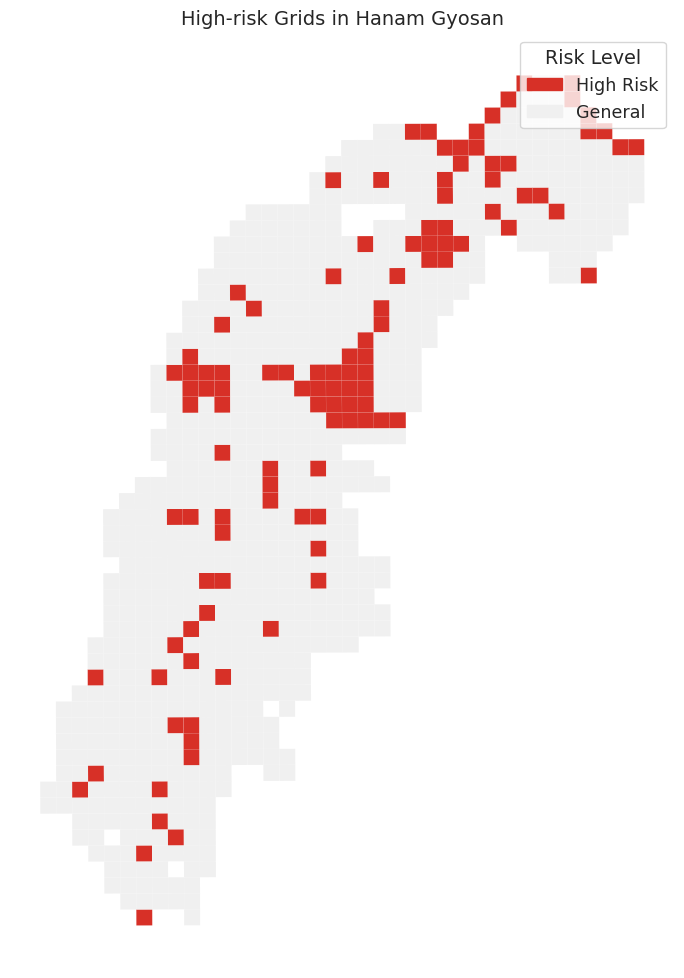

In [14]:
# High Risk Map
color_dict = {
    "High Risk": "#D73027",
    "General": "#F0F0F0"
}

fig, ax = plt.subplots(figsize=(10,10))

risk_gdf.plot(
    color=risk_gdf["risk_level"].map(color_dict),
    linewidth=0.05,
    edgecolor="white",
    ax=ax
)

import matplotlib.patches as mpatches
patches = [mpatches.Patch(color=v, label=k) for k,v in color_dict.items()]

ax.legend(handles=patches, title="Risk Level")

ax.set_title("High-risk Grids in Hanam Gyosan", fontsize=14)
ax.axis("off")

plt.tight_layout()
plt.show()

In [15]:
top_risk = risk_gdf.sort_values("risk_score", ascending=False).head(20)

top_risk[[
    "gid",
    "risk_score",
    "risk_prob",
    "risk_intensity",
    "risk_rank_pct"
]]

,gid,risk_score,risk_prob,risk_intensity,risk_rank_pct
769,다사757484,0.33962,0.45299,0.749729,0.998701
269,다사731460,0.33962,0.45299,0.749729,0.998701
582,다사741473,0.33962,0.45299,0.749729,0.998701
445,다사736469,0.33962,0.45299,0.749729,0.925325
188,다사729448,0.33962,0.45299,0.749729,0.925325
648,다사745477,0.33962,0.45299,0.749729,0.925325
644,다사744485,0.33962,0.45299,0.749729,0.925325
638,다사744479,0.33962,0.45299,0.749729,0.925325
173,다사728470,0.33962,0.45299,0.749729,0.925325
637,다사744478,0.33962,0.45299,0.749729,0.925325


In [16]:
# High Risk Grid 특성 분석

feature_cols = [
    "risk_prob",
    "risk_intensity"
]

risk_summary = risk_gdf.groupby("risk_level")[feature_cols].mean().T
risk_summary

risk_level,General,High Risk
risk_prob,0.096619,0.452990
risk_intensity,0.140116,0.749729
